In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
# Load dataset
df = pd.read_csv('D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\hyper par tune in Decisn tree-14\\heart_v2 (7).csv')

In [3]:
# Feature and target separation
X = df.drop('heart disease', axis=1)
y = df['heart disease']

In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)



In [5]:
# Function to evaluate model
def evaluate_model(model, title="Model Evaluation"):
    print(f"\n{title}")
    print("Train Accuracy :", accuracy_score(y_train, model.predict(X_train)))
    print("Train Confusion Matrix:")
    print(confusion_matrix(y_train, model.predict(X_train)))
    print("-" * 50)
    print("Test Accuracy :", accuracy_score(y_test, model.predict(X_test)))
    print("Test Confusion Matrix:")
    print(confusion_matrix(y_test, model.predict(X_test)))
    print("-" * 50)
    print("Classification Report:")
    print(classification_report(y_test, model.predict(X_test)))

In [6]:
# Function to plot decision tree
def plot_decision_tree(model, title="Decision Tree"):
    plt.figure(figsize=(20, 10))
    plot_tree(model, feature_names=X.columns, class_names=['No Disease', 'Disease'], filled=True, rounded=True)
    plt.title(title)
    plt.show()

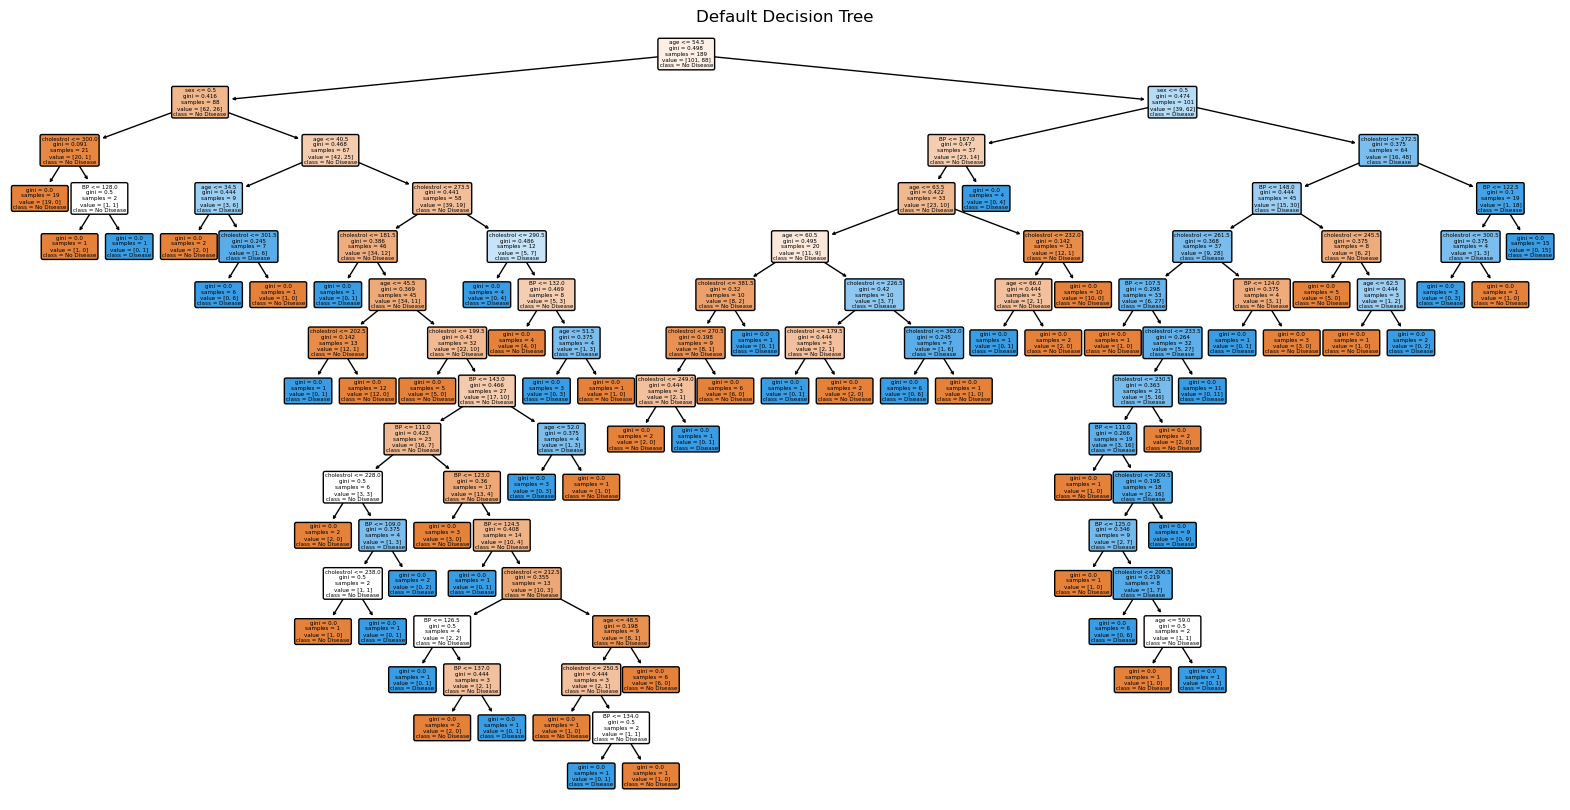


Default Decision Tree Evaluation
Train Accuracy : 1.0
Train Confusion Matrix:
[[101   0]
 [  0  88]]
--------------------------------------------------
Test Accuracy : 0.6296296296296297
Test Confusion Matrix:
[[31 18]
 [12 20]]
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.63      0.67        49
           1       0.53      0.62      0.57        32

    accuracy                           0.63        81
   macro avg       0.62      0.63      0.62        81
weighted avg       0.64      0.63      0.63        81



In [7]:
# Train and visualize default decision tree
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)
plot_decision_tree(dt_default, title="Default Decision Tree")
evaluate_model(dt_default, title="Default Decision Tree Evaluation")

In [ ]:
#Train Confusion Matrix:
#[[101   0]
 #[  0  88]]
# 101 true negatives (Class 0 : No Disease)
# 88 true positives (Class 1: Disease)
# 0 false positives and false negatives 
#sign of overfitting - model memorized taining data pefectly by may not generalize new data

#Test Accuracy : 0.6296296296296297 -- only 63% of predictions on unseen test data were correct
#Test Confusion Matrix:
#[[31 18]
# [12 20]]
# 31 true negatives
# 20 true positives
#18 false positives (predicted diseaase when there was none)
#12 false negatives (missed actual disease cases)
#Assignment - interpret classification report

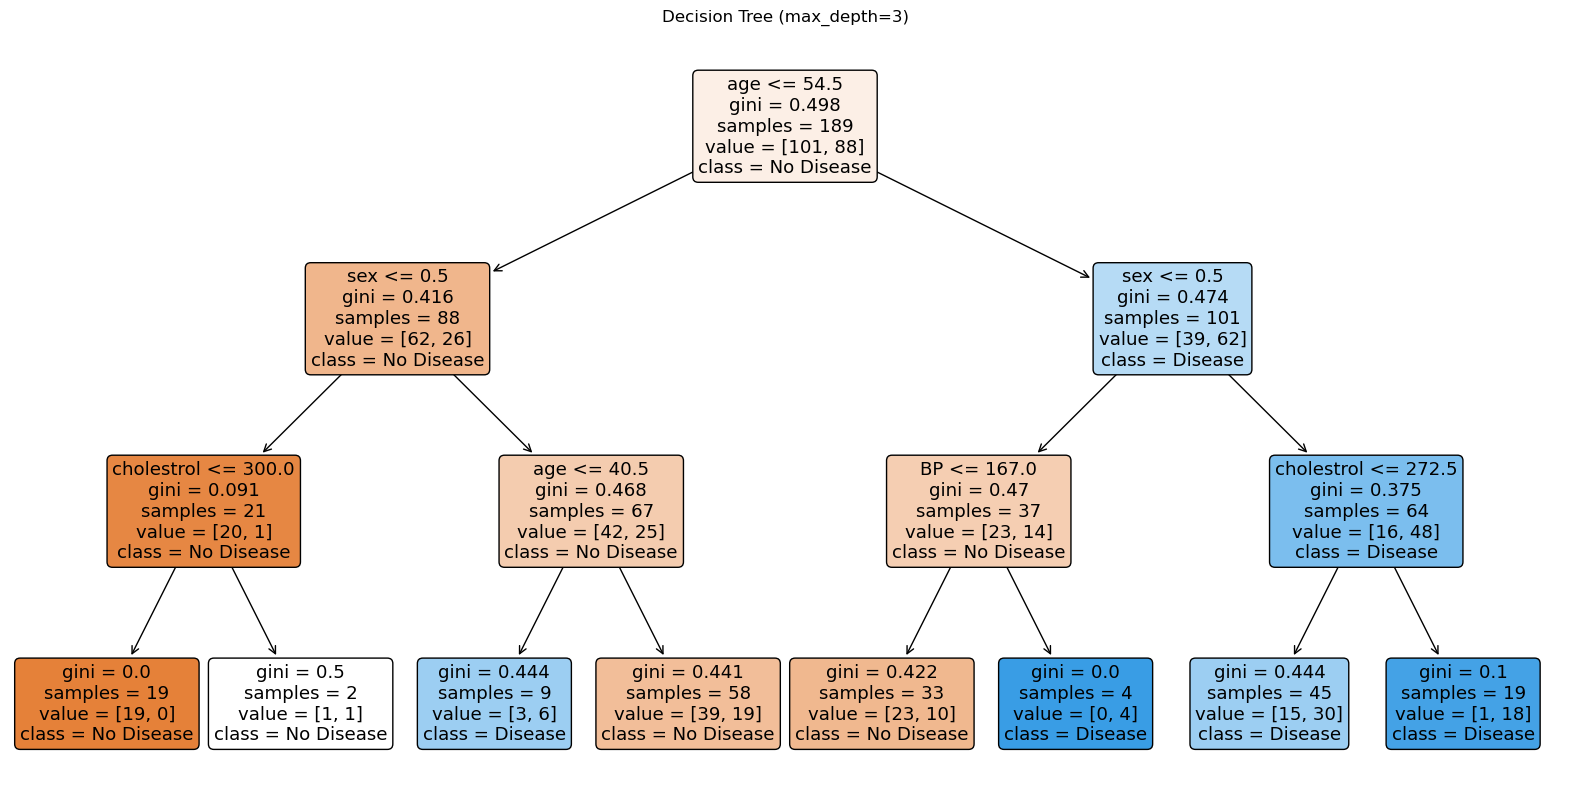


Depth-Limited Tree Evaluation
Train Accuracy : 0.7407407407407407
Train Confusion Matrix:
[[82 19]
 [30 58]]
--------------------------------------------------
Test Accuracy : 0.6049382716049383
Test Confusion Matrix:
[[35 14]
 [18 14]]
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.71      0.69        49
           1       0.50      0.44      0.47        32

    accuracy                           0.60        81
   macro avg       0.58      0.58      0.58        81
weighted avg       0.60      0.60      0.60        81



In [8]:
# Train and visualize depth-limited tree
dt_depth = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_depth.fit(X_train, y_train)
plot_decision_tree(dt_depth, title="Decision Tree (max_depth=3)")
evaluate_model(dt_depth, title="Depth-Limited Tree Evaluation")

In [ ]:
#assignment - evaluate above metrix and document your observations
#depth limiting reduced overfitting compared to default tree but it also reduced models ability to detect heart disease
#model is biased toward predicting no disease

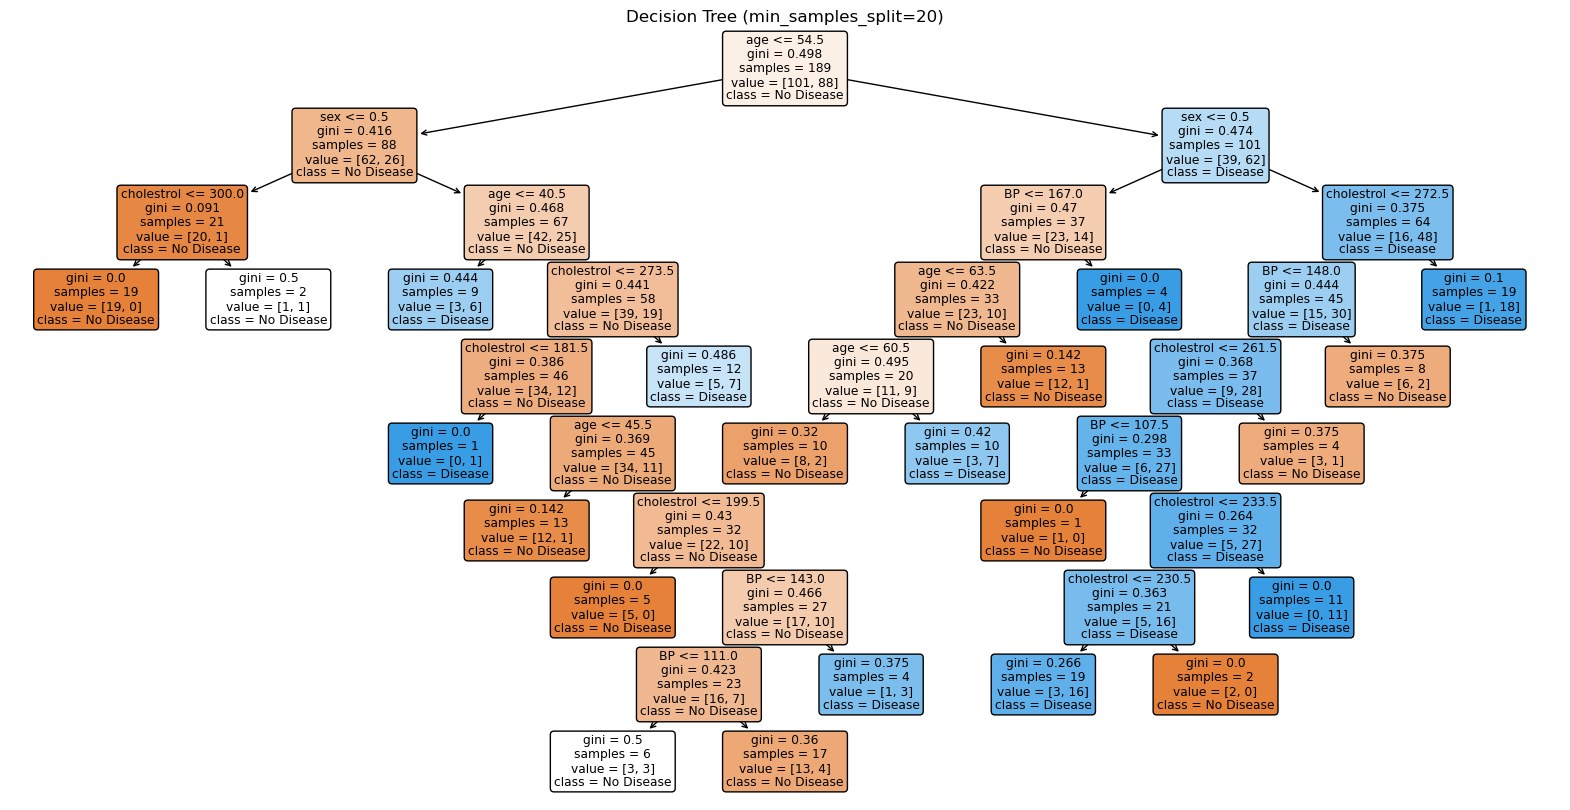


Min Samples Split Tree Evaluation
Train Accuracy : 0.8359788359788359
Train Confusion Matrix:
[[85 16]
 [15 73]]
--------------------------------------------------
Test Accuracy : 0.6419753086419753
Test Confusion Matrix:
[[32 17]
 [12 20]]
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.65      0.69        49
           1       0.54      0.62      0.58        32

    accuracy                           0.64        81
   macro avg       0.63      0.64      0.63        81
weighted avg       0.65      0.64      0.65        81



In [9]:
# Train and visualize tree with min_samples_split
dt_min_split = DecisionTreeClassifier(min_samples_split=20, random_state=42)
dt_min_split.fit(X_train, y_train)
plot_decision_tree(dt_min_split, title="Decision Tree (min_samples_split=20)")
evaluate_model(dt_min_split, title="Min Samples Split Tree Evaluation")

In [ ]:
#accuracy 64% slightly better than previous models
#macro avg - treats both classes equally
#good generalization with reduced overfitting

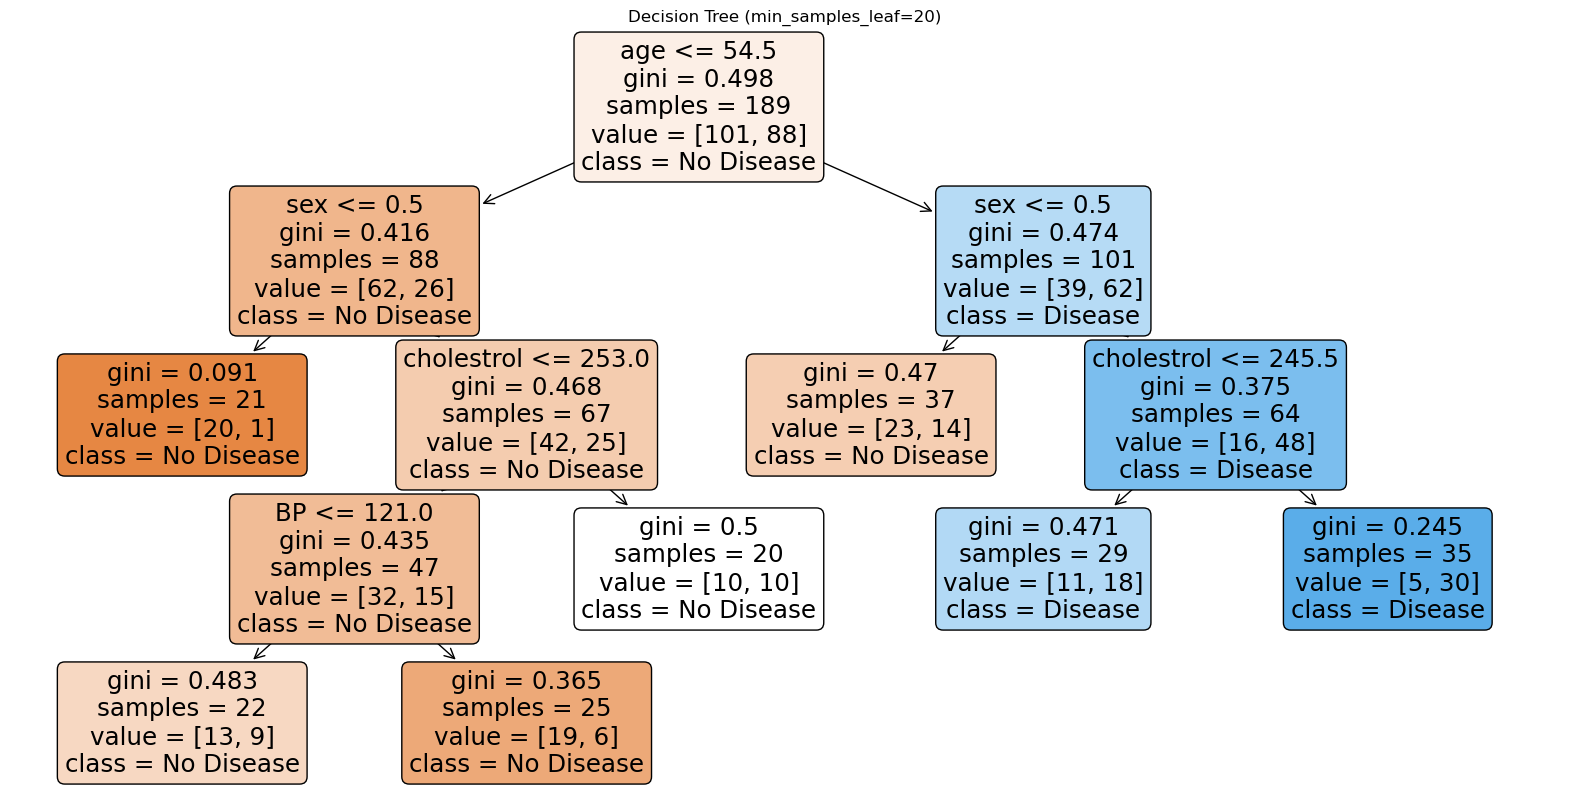


Min Samples Leaf Tree Evaluation
Train Accuracy : 0.7037037037037037
Train Confusion Matrix:
[[85 16]
 [40 48]]
--------------------------------------------------
Test Accuracy : 0.6419753086419753
Test Confusion Matrix:
[[38 11]
 [18 14]]
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.78      0.72        49
           1       0.56      0.44      0.49        32

    accuracy                           0.64        81
   macro avg       0.62      0.61      0.61        81
weighted avg       0.63      0.64      0.63        81



In [10]:
# Train and visualize tree with min_samples_leaf
dt_min_leaf = DecisionTreeClassifier(min_samples_leaf=20, random_state=42)
dt_min_leaf.fit(X_train, y_train)
plot_decision_tree(dt_min_leaf, title="Decision Tree (min_samples_leaf=20)")
evaluate_model(dt_min_leaf, title="Min Samples Leaf Tree Evaluation")

In [ ]:
# 64% consistent with previouus models

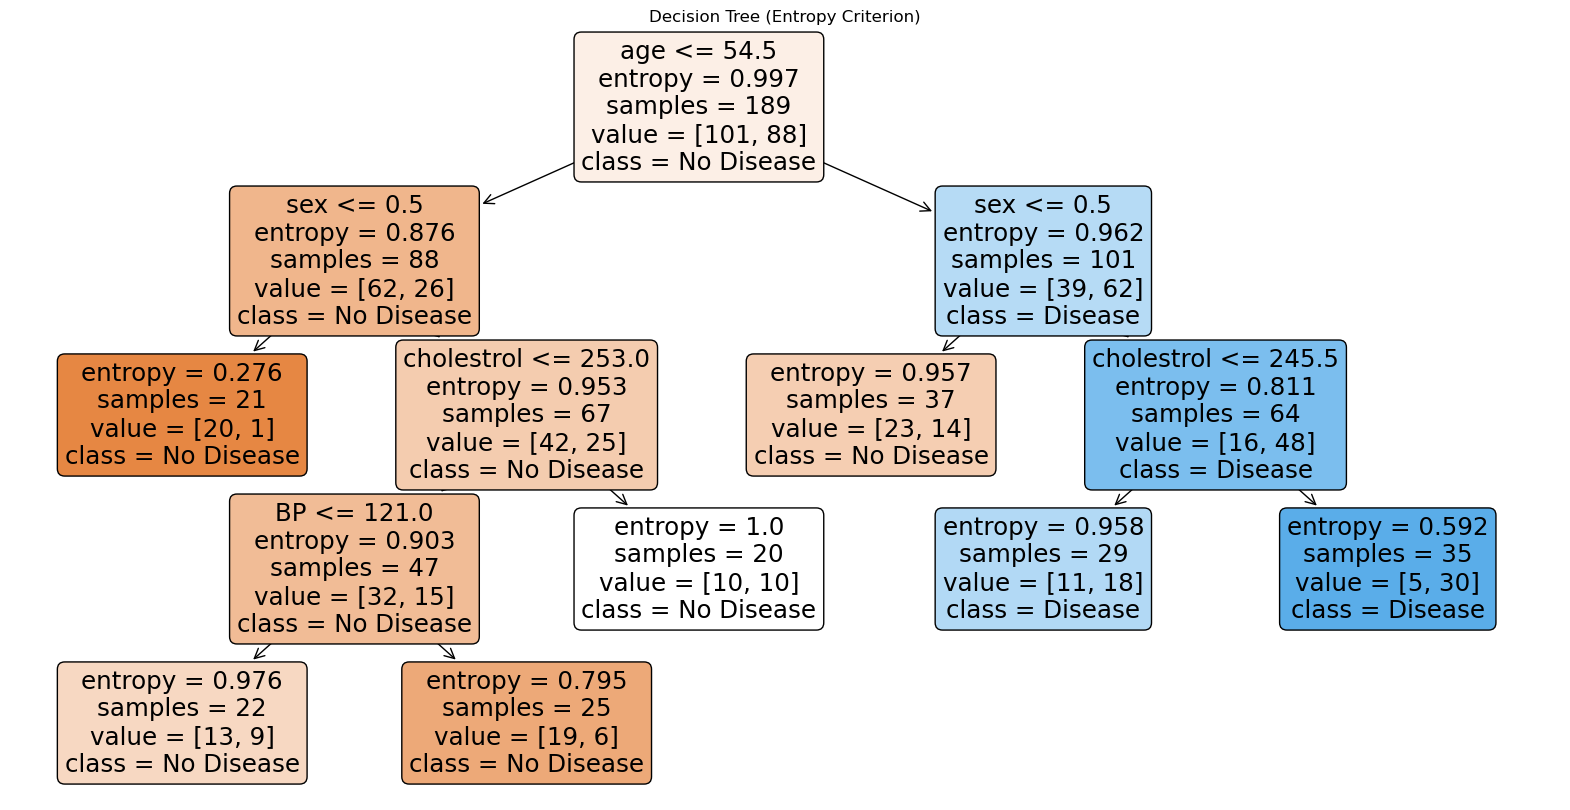


Entropy Criterion Tree Evaluation
Train Accuracy : 0.7037037037037037
Train Confusion Matrix:
[[85 16]
 [40 48]]
--------------------------------------------------
Test Accuracy : 0.6419753086419753
Test Confusion Matrix:
[[38 11]
 [18 14]]
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.78      0.72        49
           1       0.56      0.44      0.49        32

    accuracy                           0.64        81
   macro avg       0.62      0.61      0.61        81
weighted avg       0.63      0.64      0.63        81



In [11]:
# Train and visualize tree with entropy criterion
dt_entropy = DecisionTreeClassifier(min_samples_leaf=20, criterion="entropy", random_state=42)
dt_entropy.fit(X_train, y_train)
plot_decision_tree(dt_entropy, title="Decision Tree (Entropy Criterion)")
evaluate_model(dt_entropy, title="Entropy Criterion Tree Evaluation")

In [ ]:
#moderate performance
#it still struggles to detect heart disease perfectly
#high false negatives are a concern in health care application

Fitting 4 folds for each of 50 candidates, totalling 200 fits


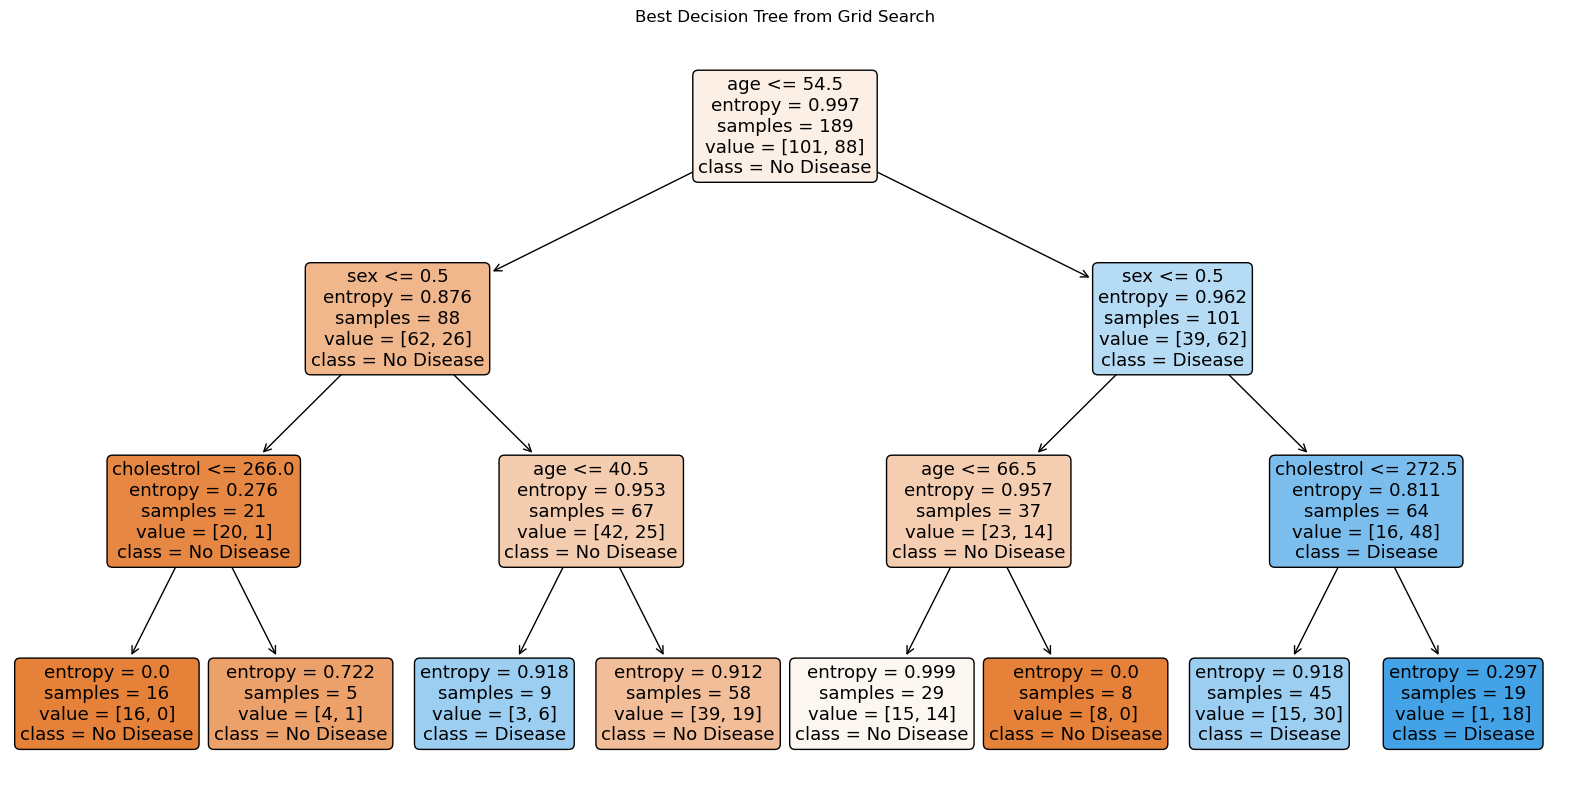


Best Decision Tree Evaluation
Train Accuracy : 0.7195767195767195
Train Confusion Matrix:
[[82 19]
 [34 54]]
--------------------------------------------------
Test Accuracy : 0.6172839506172839
Test Confusion Matrix:
[[36 13]
 [18 14]]
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.73      0.70        49
           1       0.52      0.44      0.47        32

    accuracy                           0.62        81
   macro avg       0.59      0.59      0.59        81
weighted avg       0.61      0.62      0.61        81



In [12]:
# Grid Search for best Decision Tree
params = {
    'max_depth': [2, 3, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
grid_search_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                              param_grid=params, cv=4, n_jobs=-1, verbose=1, scoring="accuracy")
grid_search_dt.fit(X_train, y_train)
dt_best = grid_search_dt.best_estimator_
plot_decision_tree(dt_best, title="Best Decision Tree from Grid Search")
evaluate_model(dt_best, title="Best Decision Tree Evaluation")

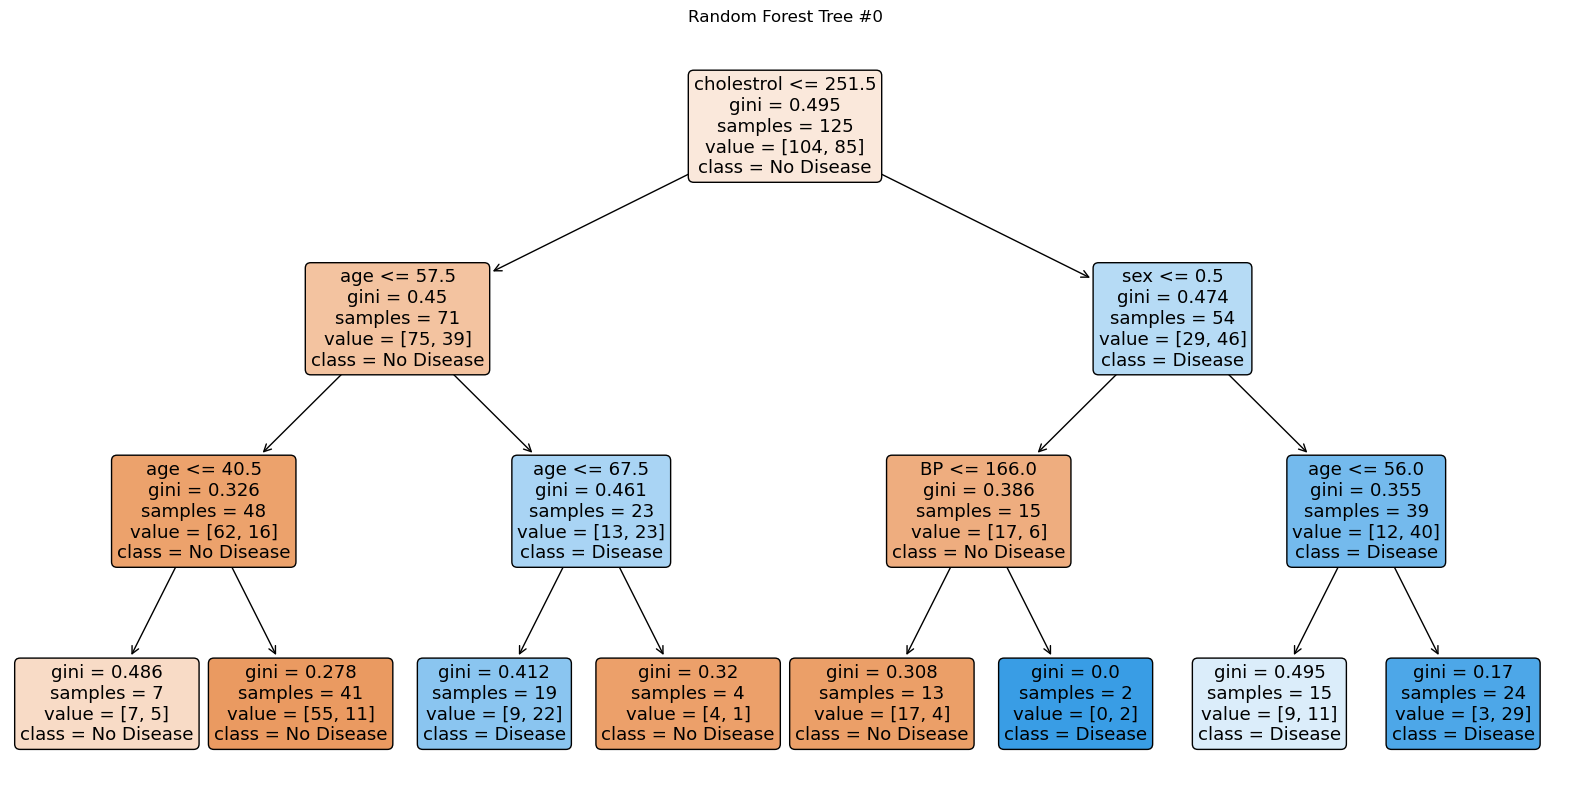


Random Forest Evaluation
Train Accuracy : 0.7407407407407407
Train Confusion Matrix:
[[80 21]
 [28 60]]
--------------------------------------------------
Test Accuracy : 0.6172839506172839
Test Confusion Matrix:
[[35 14]
 [17 15]]
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        49
           1       0.52      0.47      0.49        32

    accuracy                           0.62        81
   macro avg       0.60      0.59      0.59        81
weighted avg       0.61      0.62      0.61        81



In [13]:
# Train Random Forest and visualize one tree
rf = RandomForestClassifier(random_state=42, n_estimators=10, max_depth=3)
rf.fit(X_train, y_train)
plot_decision_tree(rf.estimators_[0], title="Random Forest Tree #0")
evaluate_model(rf, title="Random Forest Evaluation")

Fitting 4 folds for each of 375 candidates, totalling 1500 fits


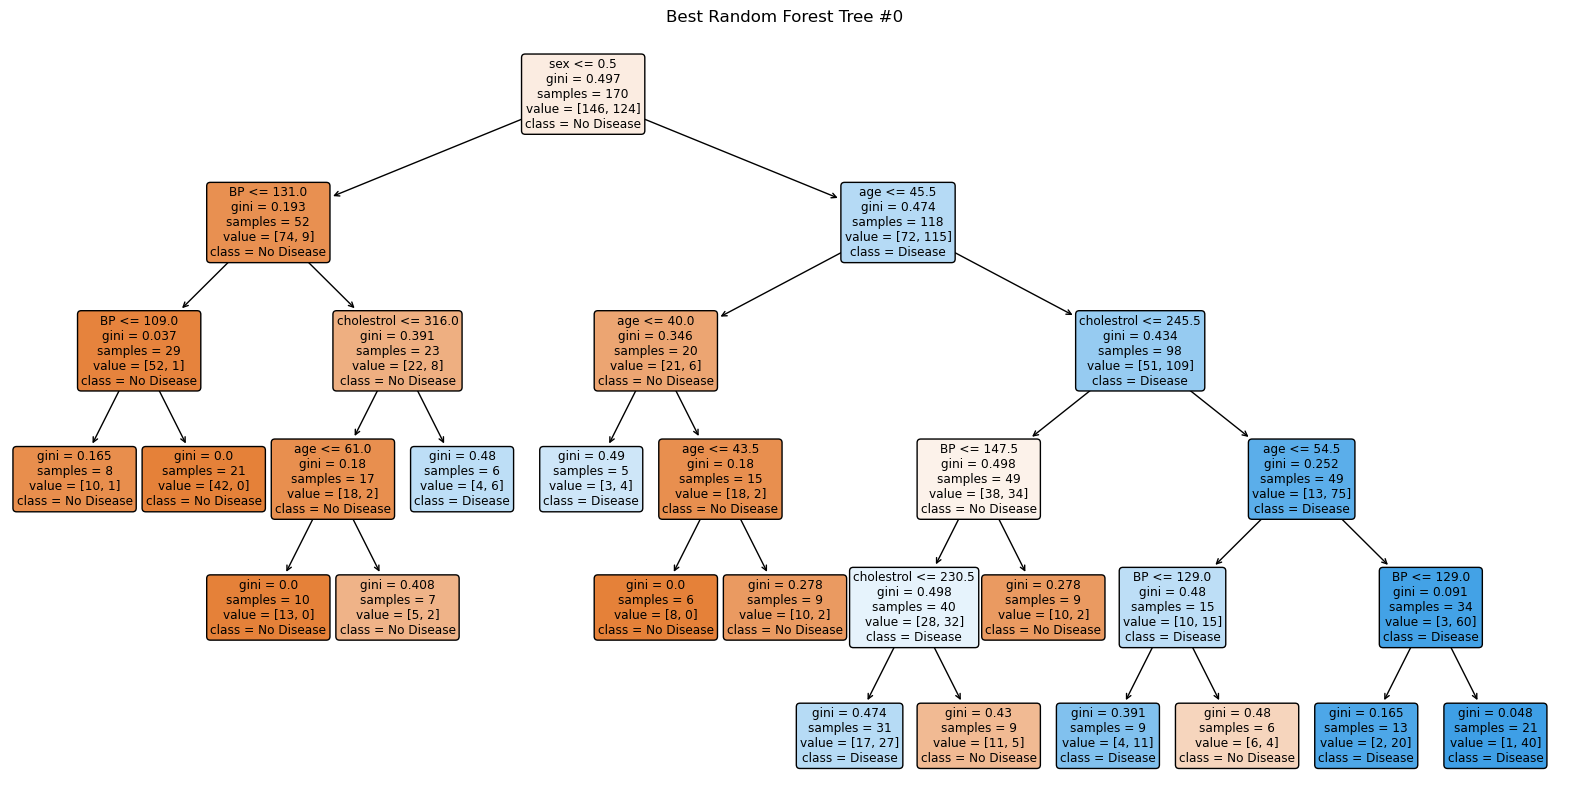


Best Random Forest Evaluation
Train Accuracy : 0.8042328042328042
Train Confusion Matrix:
[[87 14]
 [23 65]]
--------------------------------------------------
Test Accuracy : 0.8024691358024691
Test Confusion Matrix:
[[42  7]
 [ 9 23]]
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        49
           1       0.77      0.72      0.74        32

    accuracy                           0.80        81
   macro avg       0.80      0.79      0.79        81
weighted avg       0.80      0.80      0.80        81



In [14]:
# Grid Search for best Random Forest
params_rf = {
    'max_depth': [1, 2, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'max_features': [2, 3, 4],
    'n_estimators': [10, 30, 50, 100, 200]
}
grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
                              param_grid=params_rf, cv=4, n_jobs=-1, verbose=1, scoring="accuracy")
grid_search_rf.fit(X, y)
rf_best = grid_search_rf.best_estimator_
plot_decision_tree(rf_best.estimators_[0], title="Best Random Forest Tree #0")
evaluate_model(rf_best, title="Best Random Forest Evaluation")

In [ ]:
#from above output
#best performing model so far
#low false negatives
#generalizes well

In [15]:
# Feature Importance
classifier_rf = RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=5, n_estimators=100, oob_score=True)
classifier_rf.fit(X_train, y_train)
imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": classifier_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

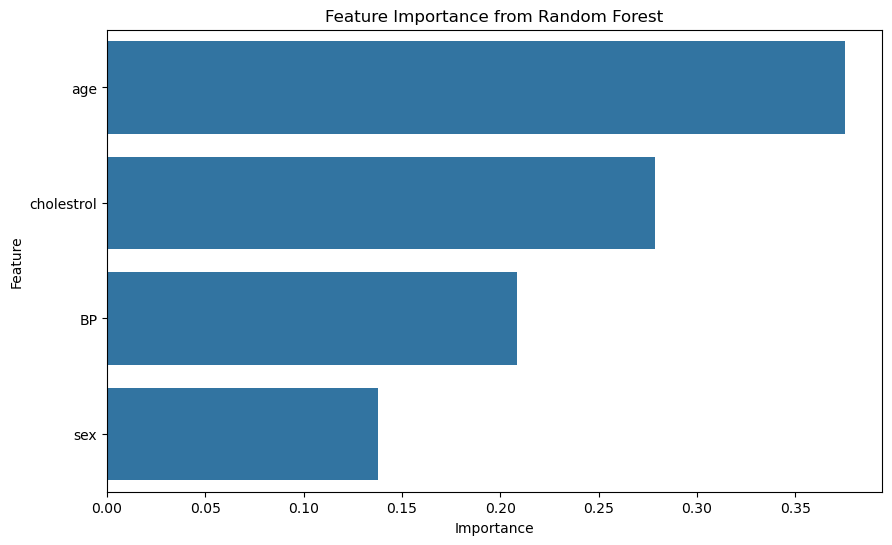

In [16]:
# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=imp_df)
plt.title("Feature Importance from Random Forest")
plt.show()

In [ ]:
#Project/assignment - try on other data sets from kaggle 
#document your observations.